In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [3]:
# Load dataset (replace with your file path)
df = pd.read_csv(r"D:\Sem 4\ML\ml project\data\diabetic_data.csv")# Inspect first few rows


 # update path if needed

df.replace('?', np.nan, inplace=True)

print('Dataset Shape:', df.shape)
print('\nTarget Distribution:')
print(df['readmitted'].value_counts())
print('\nMissing Values (%):')
miss = (df.isnull().sum() / len(df) * 100).round(1)
print(miss[miss > 0].sort_values(ascending=False))

Dataset Shape: (101766, 50)

Target Distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Missing Values (%):
weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
dtype: float64


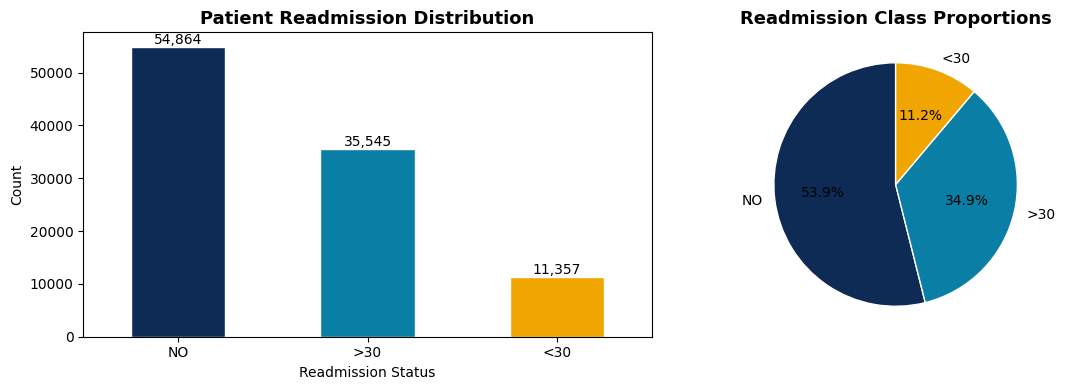

✅ Figure 1 saved


In [4]:
colors = ['#0D2B55', '#0A7EA4', '#F0A500']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Patient Readmission Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

df['readmitted'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Readmission Class Proportions', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

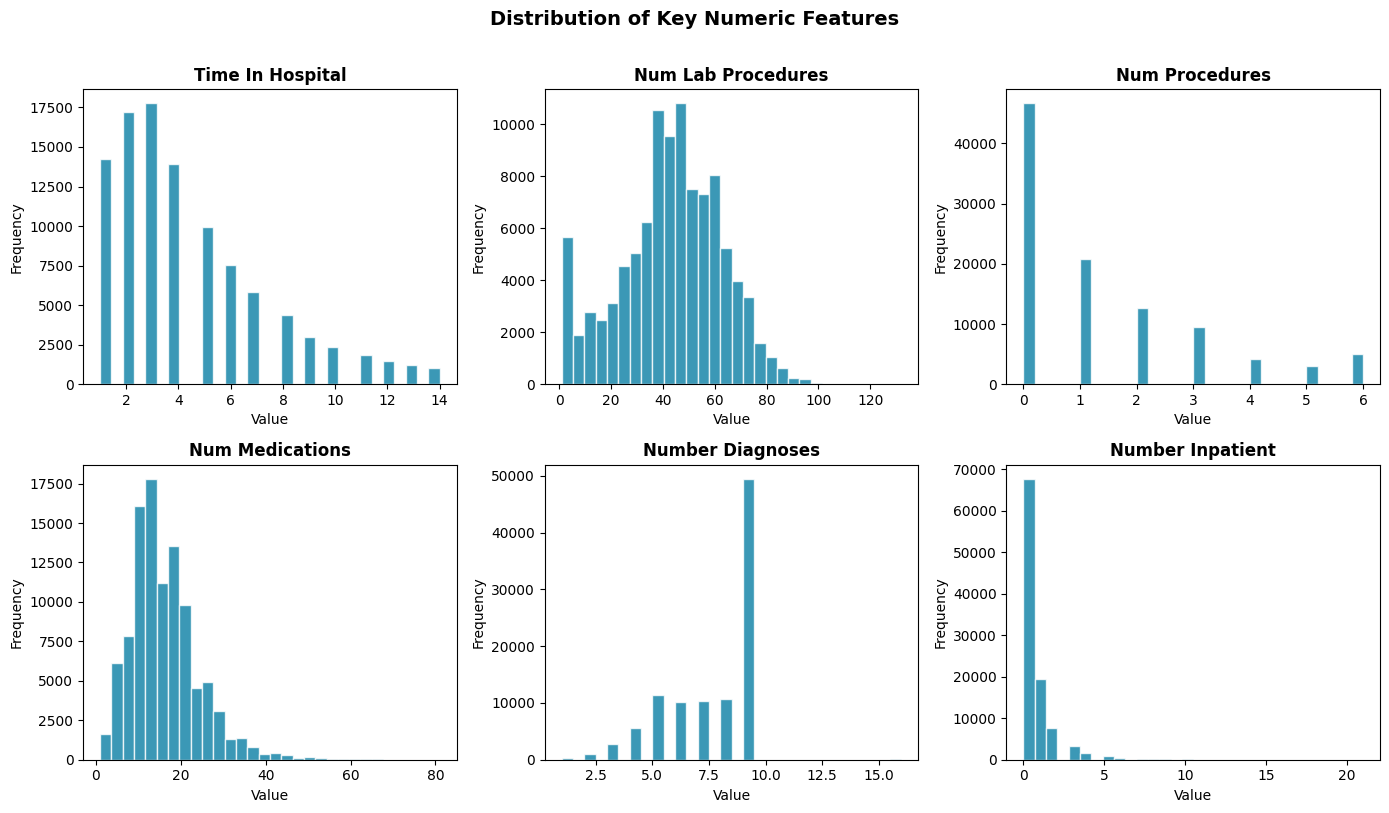

✅ Figure 2 saved


In [5]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_inpatient']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#0A7EA4', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

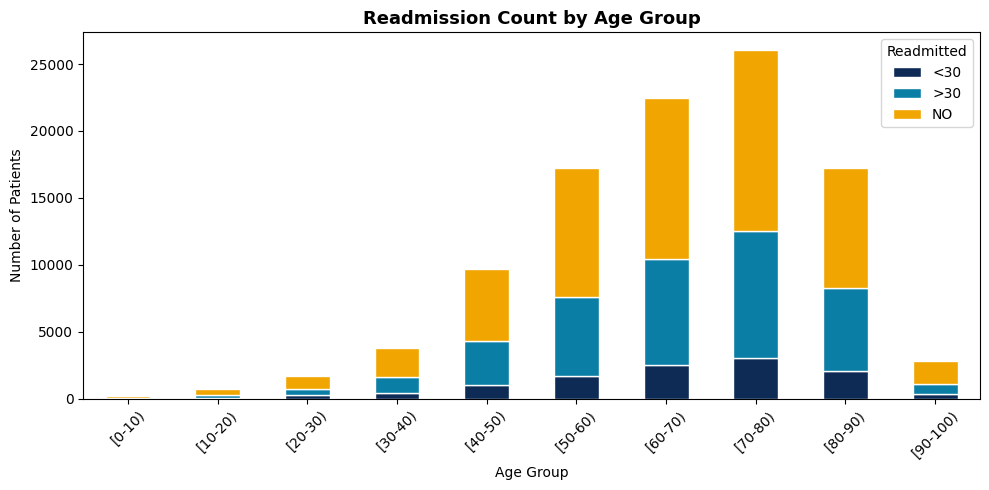

✅ Figure 3 saved


In [6]:
age_read = df.groupby(['age', 'readmitted']).size().unstack(fill_value=0)
age_read.plot(kind='bar', stacked=True, color=colors, figsize=(10, 5), edgecolor='white')
plt.title('Readmission Count by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.savefig('fig3_age_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

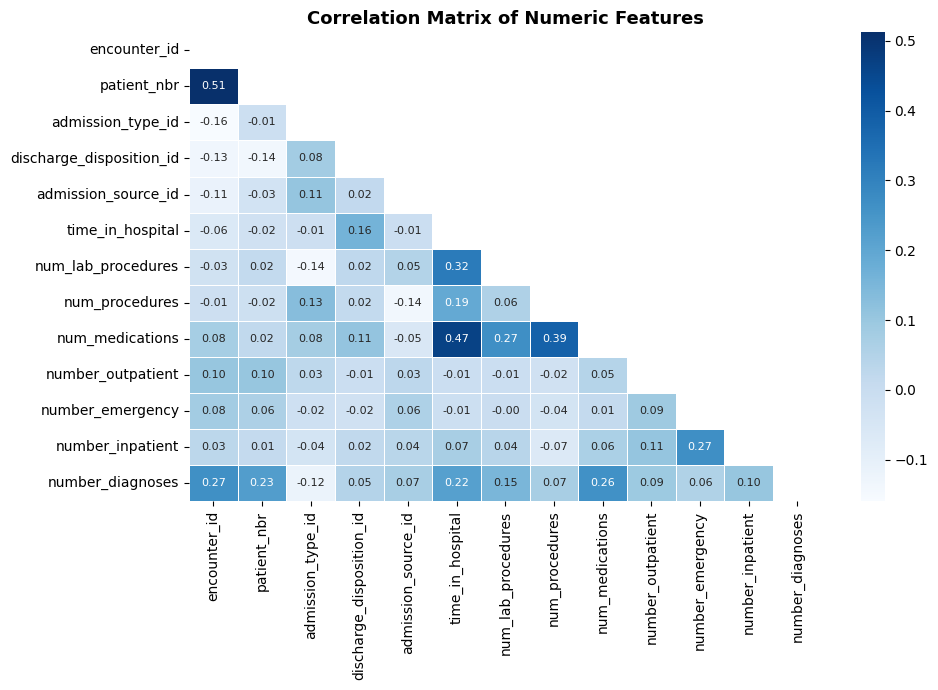

✅ Figure 4 saved


In [7]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 4 saved')

In [8]:
# Drop irrelevant or high-missing columns
drop_cols = [
    'encounter_id', 'patient_nbr',
    'weight', 'max_glu_serum', 'A1Cresult',
    'payer_code', 'medical_specialty',
    'acetohexamide', 'tolbutamide', 'troglitazone',
    'examide', 'citoglipton',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df_clean = df.drop(columns=drop_cols)
print(f'Columns after dropping: {df_clean.shape[1]} (was {df.shape[1]})')

# Fill missing values
df_clean['race'].fillna(df_clean['race'].mode()[0], inplace=True)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col].fillna('Unknown', inplace=True)

# Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_clean)}')
print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')
print('✅ Cleaning complete')

Columns after dropping: 35 (was 50)
Duplicates removed: 0
Missing values remaining: 4075
✅ Cleaning complete


In [9]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide',
            'insulin', 'glyburide-metformin', 'glipizide-metformin']

# New feature: count of active medications
df_clean['total_meds_active'] = (df_clean[med_cols] != 'No').sum(axis=1)

# New feature: total service utilisation
df_clean['service_utilisation'] = (
    df_clean['number_outpatient'] +
    df_clean['number_emergency'] +
    df_clean['number_inpatient']
)

print('New features added:')
print(df_clean[['total_meds_active', 'service_utilisation']].describe().round(2))

New features added:
       total_meds_active  service_utilisation
count          101766.00            101766.00
mean                1.18                 1.20
std                 0.92                 2.29
min                 0.00                 0.00
25%                 1.00                 0.00
50%                 1.00                 0.00
75%                 2.00                 2.00
max                 6.00                80.00


In [10]:
# Encode target
target_map = {'NO': 0, '>30': 1, '<30': 2}
df_clean['readmitted'] = df_clean['readmitted'].map(target_map)

X = df_clean.drop('readmitted', axis=1)
y = df_clean['readmitted']

# Encode all categorical columns
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Features: {X.shape[1]}')
print(f'Samples : {len(y):,}')
print('\nTarget distribution:')
print(y.value_counts().sort_index())
print('\n0 = NO  |  1 = >30 days  |  2 = <30 days')

Features: 36
Samples : 101,766

Target distribution:
readmitted
0    54864
1    35545
2    11357
Name: count, dtype: int64

0 = NO  |  1 = >30 days  |  2 = <30 days


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print('=== Split Summary ===')
print(f'Train : {len(X_train):,}')
print(f'Test  : {len(X_test):,}')

# Scale — fit on train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\n✅ Scaling done')
print(f'Train mean ≈ {X_train_s.mean():.4f} (should be ~0)')
print(f'Train std  ≈ {X_train_s.std():.4f}  (should be ~1)')

=== Split Summary ===
Train : 71,236
Test  : 30,530

✅ Scaling done
Train mean ≈ 0.0000 (should be ~0)
Train std  ≈ 1.0000  (should be ~1)


KNN — Accuracy: 0.5365 | F1: 0.4914
              precision    recall  f1-score   support

          NO       0.58      0.80      0.67     16459
         >30       0.43      0.29      0.35     10664
         <30       0.23      0.04      0.07      3407

    accuracy                           0.54     30530
   macro avg       0.41      0.38      0.36     30530
weighted avg       0.49      0.54      0.49     30530



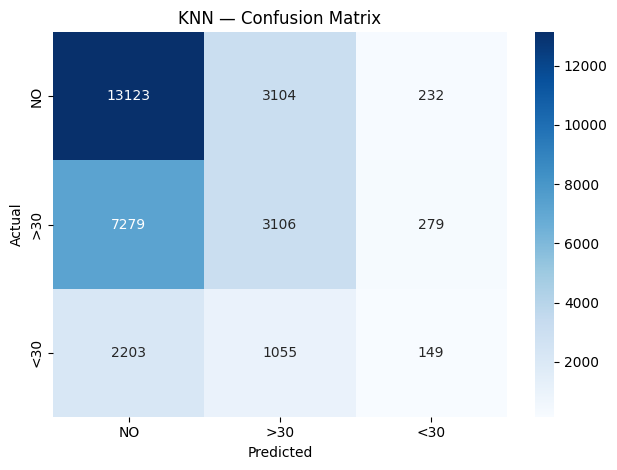

In [12]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='weighted')
print(f'KNN — Accuracy: {acc_knn:.4f} | F1: {f1_knn:.4f}')
print(classification_report(y_test, y_pred_knn, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('KNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Decision Tree — Accuracy: 0.5766 | F1: 0.5268
              precision    recall  f1-score   support

          NO       0.61      0.84      0.70     16459
         >30       0.49      0.35      0.41     10664
         <30       0.37      0.02      0.04      3407

    accuracy                           0.58     30530
   macro avg       0.49      0.40      0.38     30530
weighted avg       0.54      0.58      0.53     30530



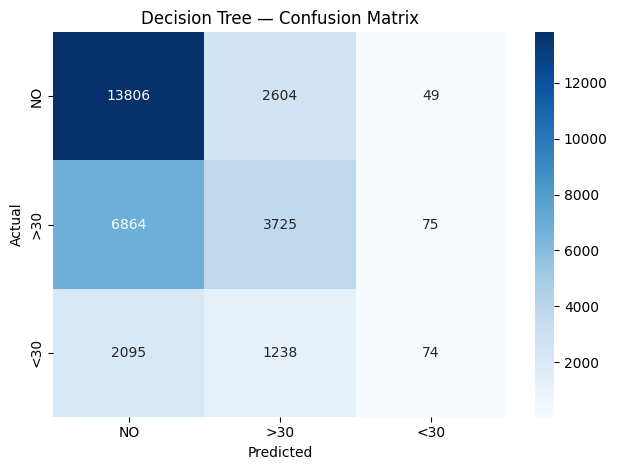

In [13]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=50,
                             min_samples_leaf=20, random_state=42)
dt.fit(X_train_s, y_train)
y_pred_dt = dt.predict(X_test_s)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')
print(f'Decision Tree — Accuracy: {acc_dt:.4f} | F1: {f1_dt:.4f}')
print(classification_report(y_test, y_pred_dt, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Logistic Regression — Accuracy: 0.5705 | F1: 0.4970
              precision    recall  f1-score   support

          NO       0.58      0.90      0.71     16459
         >30       0.50      0.23      0.32     10664
         <30       0.36      0.01      0.02      3407

    accuracy                           0.57     30530
   macro avg       0.48      0.38      0.35     30530
weighted avg       0.53      0.57      0.50     30530



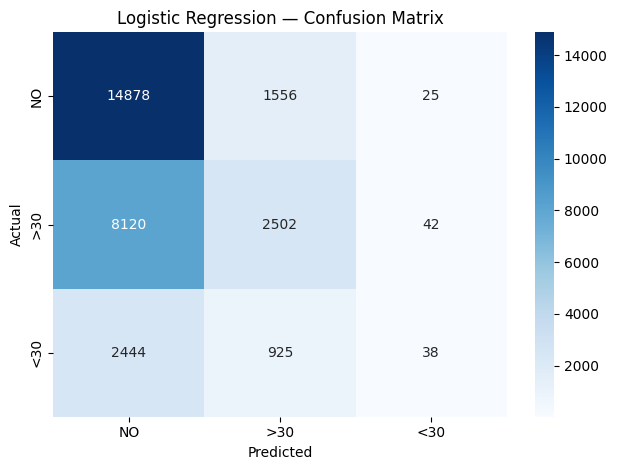

In [14]:
lr = LogisticRegression(max_iter=1000, solver='saga', C=1.0, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')
print(f'Logistic Regression — Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

SVM — Accuracy: 0.5676 | F1: 0.4844
              precision    recall  f1-score   support

          NO       0.58      0.92      0.71     16459
         >30       0.50      0.20      0.29     10664
         <30       0.00      0.00      0.00      3407

    accuracy                           0.57     30530
   macro avg       0.36      0.37      0.33     30530
weighted avg       0.49      0.57      0.48     30530



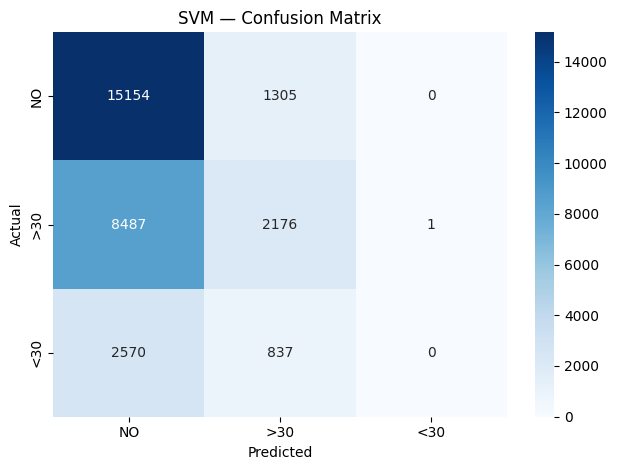

In [15]:
svm = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')
print(f'SVM — Accuracy: {acc_svm:.4f} | F1: {f1_svm:.4f}')
print(classification_report(y_test, y_pred_svm, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('SVM — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Naive Bayes — Accuracy: 0.1186 | F1: 0.0406
              precision    recall  f1-score   support

          NO       0.54      0.01      0.01     16459
         >30       0.44      0.02      0.03     10664
         <30       0.11      0.98      0.20      3407

    accuracy                           0.12     30530
   macro avg       0.36      0.33      0.08     30530
weighted avg       0.46      0.12      0.04     30530



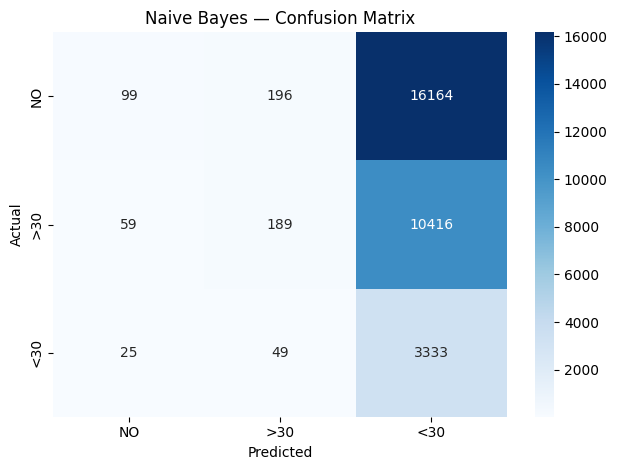

In [16]:
nb = GaussianNB(var_smoothing=1e-9)
nb.fit(X_train_s, y_train)
y_pred_nb = nb.predict(X_test_s)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted')
print(f'Naive Bayes — Accuracy: {acc_nb:.4f} | F1: {f1_nb:.4f}')
print(classification_report(y_test, y_pred_nb, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'])
plt.title('Naive Bayes — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Random Forest — Accuracy: 0.5472 | F1: 0.5471
              precision    recall  f1-score   support

          NO       0.66      0.68      0.67     16459
         >30       0.47      0.44      0.45     10664
         <30       0.23      0.25      0.24      3407

    accuracy                           0.55     30530
   macro avg       0.45      0.46      0.46     30530
weighted avg       0.55      0.55      0.55     30530



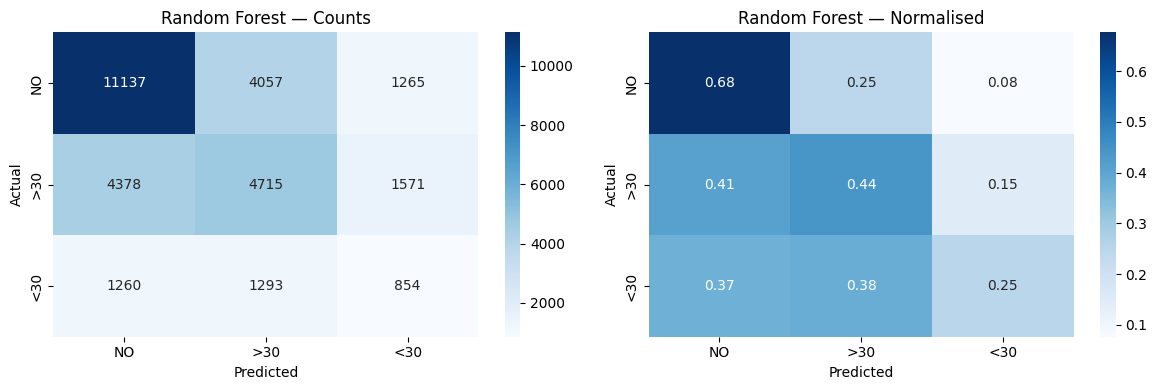

In [17]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest — Accuracy: {acc_rf:.4f} | F1: {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['NO', '>30', '<30']))

cm = confusion_matrix(y_test, y_pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'], ax=axes[0])
axes[0].set_title('Random Forest — Counts')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['NO','>30','<30'], yticklabels=['NO','>30','<30'], ax=axes[1])
axes[1].set_title('Random Forest — Normalised')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('fig6_confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  F1-Score
Decision Tree          0.5766    0.5268
Logistic Regression    0.5705    0.4970
SVM                    0.5676    0.4844
Random Forest          0.5472    0.5471
KNN                    0.5365    0.4914
Naive Bayes            0.1186    0.0406


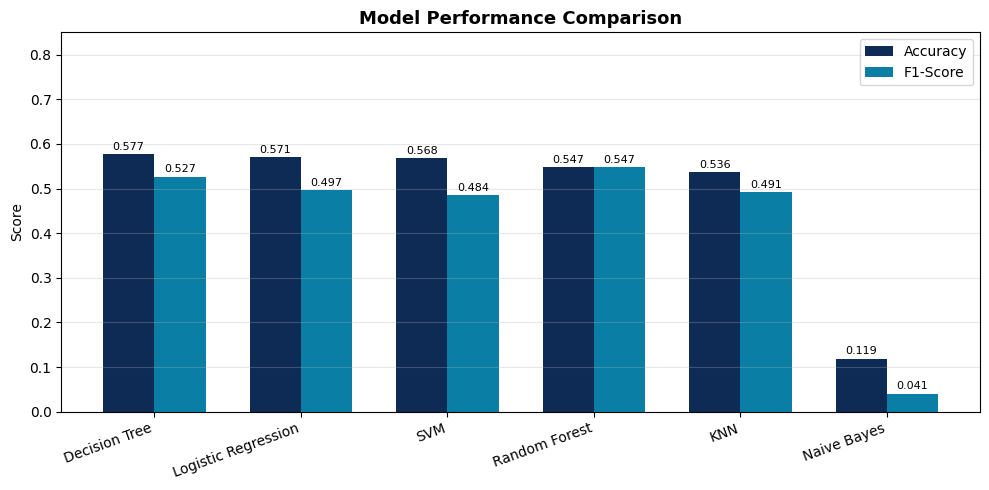

In [18]:
results = {
    'KNN':                 {'Accuracy': acc_knn, 'F1-Score': f1_knn},
    'Decision Tree':       {'Accuracy': acc_dt,  'F1-Score': f1_dt},
    'Logistic Regression': {'Accuracy': acc_lr,  'F1-Score': f1_lr},
    'SVM':                 {'Accuracy': acc_svm, 'F1-Score': f1_svm},
    'Naive Bayes':         {'Accuracy': acc_nb,  'F1-Score': f1_nb},
    'Random Forest':       {'Accuracy': acc_rf,  'F1-Score': f1_rf},
}

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False).round(4)
print('=== MODEL PERFORMANCE COMPARISON ===')
print(results_df)

x = np.arange(len(results_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy',  color='#0D2B55')
bars2 = ax.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='#0A7EA4')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 0.85)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

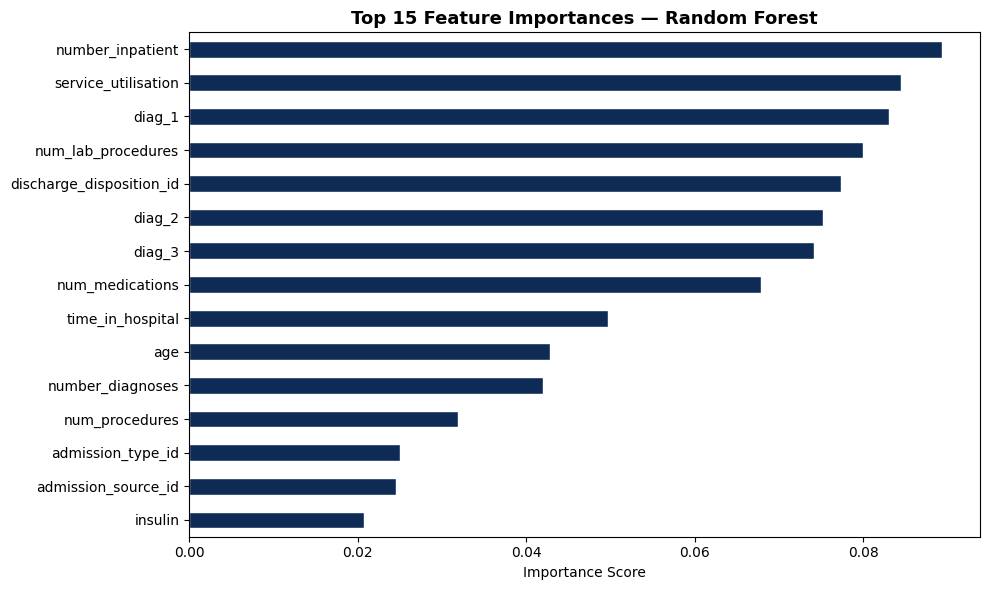


Top 10 Features:
number_inpatient            0.0894
service_utilisation         0.0845
diag_1                      0.0831
num_lab_procedures          0.0800
discharge_disposition_id    0.0773
diag_2                      0.0752
diag_3                      0.0742
num_medications             0.0679
time_in_hospital            0.0497
age                         0.0429
dtype: float64


In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='#0D2B55', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 10 Features:')
print(top15.head(10).round(4))

Model                   Train Acc   Test Acc      Gap       Diagnosis
----------------------------------------------------------------------
KNN                        0.6498     0.5365   0.1133     Overfitting
Decision Tree              0.5841     0.5766   0.0075        Balanced
Logistic Regression        0.5710     0.5705   0.0005        Balanced
SVM                        0.5689     0.5676   0.0012        Balanced
Naive Bayes                0.1191     0.1186   0.0005    Underfitting
Random Forest              0.6712     0.5472   0.1240     Overfitting


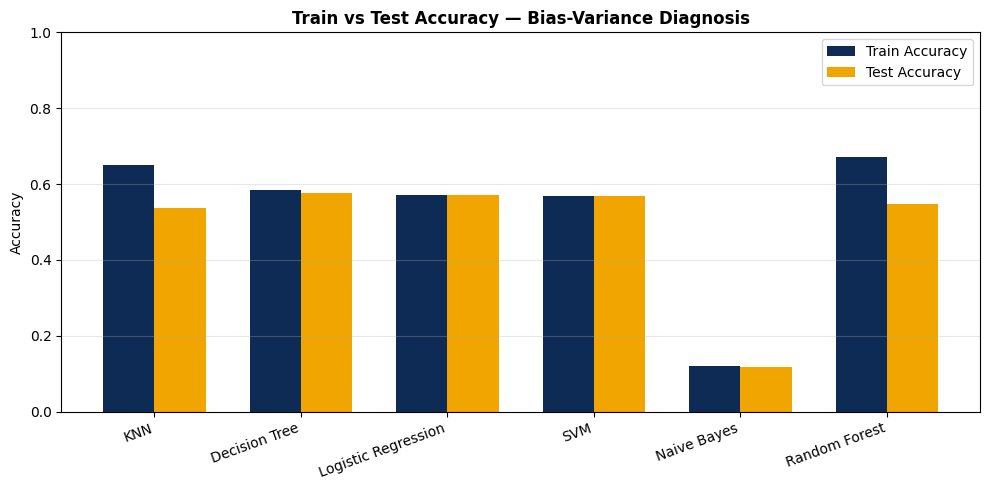

In [20]:
print(f'{"Model":<22} {"Train Acc":>10} {"Test Acc":>10} {"Gap":>8} {"Diagnosis":>15}')
print('-' * 70)

all_models = {
    'KNN': (knn, y_pred_knn), 'Decision Tree': (dt, y_pred_dt),
    'Logistic Regression': (lr, y_pred_lr), 'SVM': (svm, y_pred_svm),
    'Naive Bayes': (nb, y_pred_nb), 'Random Forest': (rf, y_pred_rf),
}

bias_results = {}
for name, (model, y_pred) in all_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_s))
    test_acc  = accuracy_score(y_test, y_pred)
    gap = train_acc - test_acc
    diagnosis = 'Overfitting' if gap > 0.10 else ('Underfitting' if test_acc < 0.55 else 'Balanced')
    bias_results[name] = {'Train': train_acc, 'Test': test_acc, 'Gap': gap, 'Diagnosis': diagnosis}
    print(f'{name:<22} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f} {diagnosis:>15}')

bias_df = pd.DataFrame(bias_results).T
x = np.arange(len(bias_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, bias_df['Train'].astype(float), width, label='Train Accuracy', color='#0D2B55')
ax.bar(x + width/2, bias_df['Test'].astype(float),  width, label='Test Accuracy',  color='#F0A500')
ax.set_xticks(x)
ax.set_xticklabels(bias_df.index, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title('Train vs Test Accuracy — Bias-Variance Diagnosis', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

Logistic Regression: Mean=0.5744 ± 0.0033  Folds=[np.float64(0.5693), np.float64(0.5758), np.float64(0.5765), np.float64(0.5718), np.float64(0.5784)]
Decision Tree: Mean=0.5652 ± 0.0082  Folds=[np.float64(0.5491), np.float64(0.5688), np.float64(0.5721), np.float64(0.5669), np.float64(0.5693)]
Random Forest: Mean=0.5380 ± 0.0089  Folds=[np.float64(0.5241), np.float64(0.5372), np.float64(0.5508), np.float64(0.5346), np.float64(0.5435)]


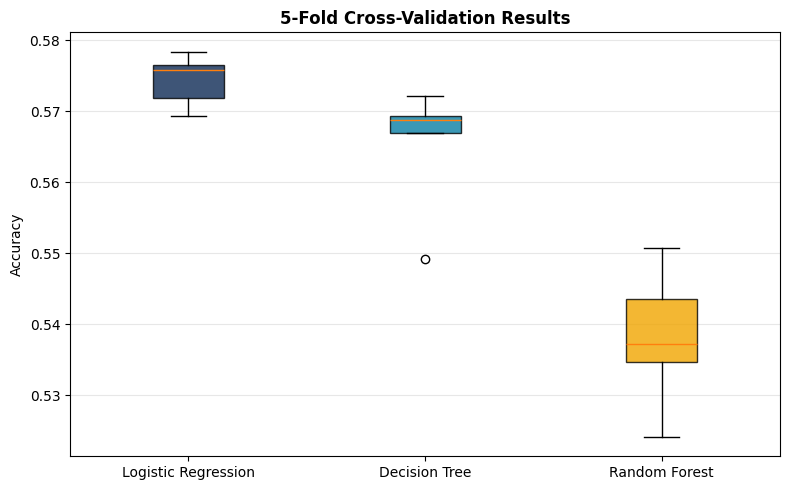

In [21]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.7, random_state=42)
for train_idx, _ in sss.split(X_train_s, y_train):
    X_cv = X_train_s[train_idx]
    y_cv = y_train.iloc[train_idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=50, max_depth=10,
                                                   class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: Mean={scores.mean():.4f} ± {scores.std():.4f}  Folds={[round(s,4) for s in scores]}')

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cv_results[m] for m in cv_models], labels=list(cv_models.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], ['#0D2B55', '#0A7EA4', '#F0A500']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Results', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print('=' * 55)
print('        FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'{"Model":<22} {"Accuracy":>10} {"F1-Score":>10}')
print('-' * 55)
for name, row in results_df.iterrows():
    marker = ' ✅ BEST' if name == results_df.index[0] else ''
    print(f'{name:<22} {row["Accuracy"]:>10.4f} {row["F1-Score"]:>10.4f}{marker}')
print('=' * 55)
best = results_df.index[0]
print(f'\nBest Model : {best}')
print(f'Accuracy   : {results_df.loc[best,"Accuracy"]*100:.1f}%')
print(f'F1-Score   : {results_df.loc[best,"F1-Score"]:.4f}')
print(f'\nNote: 3-class imbalanced problem — majority class baseline = ~54%')

        FINAL MODEL PERFORMANCE SUMMARY
Model                    Accuracy   F1-Score
-------------------------------------------------------
Decision Tree              0.5766     0.5268 ✅ BEST
Logistic Regression        0.5705     0.4970
SVM                        0.5676     0.4844
Random Forest              0.5472     0.5471
KNN                        0.5365     0.4914
Naive Bayes                0.1186     0.0406

Best Model : Decision Tree
Accuracy   : 57.7%
F1-Score   : 0.5268

Note: 3-class imbalanced problem — majority class baseline = ~54%
